# 6회차 | 분류 모델 평가지표

**핵심 질문**: 정확도 90%를 믿어도 되나?

**오늘의 목표**
1. **정확도(Accuracy)의 함정**: 왜 때로는 위험한가 (불균형 데이터에서 착시)
2. **혼동행렬(Confusion Matrix)**: 무엇을 많이 틀렸는지 보기 (TP/FP/FN/TN)
3. **정밀도(Precision), 재현율(Recall), F1**: 의미와 해석
4. **임곗값(Threshold)**: 바꾸면 지표가 어떻게 달라지는지
5. **ROC 곡선과 AUC, PR 곡선(AP)**: 전체 임곗값에서의 분류력 요약


---
## 평가지표를 다루는 이유

**모델을 선택하는 기준과 전처리를 배웠었음**
하지만 **"Accuracy(정확도)"만 보면 삐용비용**

### 왜 정확도만 보면 안 되는가?

| 상황 | 정확도 | 실제 성능 |
|------|--------|----------|
| 암 환자 1%, 건강한 사람 99% | "모두 건강"이라고 예측 → 99% | 암 환자를 **전혀 못 찾음** |
| 스팸 10%, 정상 90% | "모두 정상"이라고 예측 → 90% | 스팸을 **전혀 못 걸러냄** |

> **3회차 핵심 문장:**  
> "정확도 90%가 좋은 게 아니라, **무엇을 맞추고 무엇을 틀렸는지**가 중요"

### 오늘 쓸 지표 요약

| 지표 | 의미 | 언제 중요한가 |
|------|------|-------------|
| **정확도(Accuracy)** | 전체 중 맞춘 비율 | 클래스가 균형일 때 |
| **정밀도(Precision)** | 양성 예측 중 실제 양성 | 오탐을 줄여야 할 때 (스팸) |
| **재현율(Recall)** | 실제 양성 중 찾은 비율 | 누락을 줄여야 할 때 (암) |
| **F1** | Precision과 Recall의 균형 | 둘 다 중요할 때 |
| **ROC-AUC** | 전체 임곗값에서 분류력 | 균형 데이터 성능 요약 |
| **PR-AP** | 양성 기준 분류력 | 불균형 데이터 성능 요약 |

In [24]:
import sklearn, numpy as np, pandas as pd
import plotly.express as px
import plotly.graph_objects as go
print("sklearn:", sklearn.__version__)
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)

sklearn: 1.6.1
numpy  : 2.0.2
pandas : 2.3.3


---
## Part 1. Accuracy(정확도)의 함정

### Titanic 데이터로 Dummy 분류기 만들기

**Titanic 데이터셋 소개**
- 실제 타이타닉호 생존자 데이터를 정리한 유명한 공개 데이터셋
- 목표: 승객의 나이, 성별, 선실 등급 등을 보고 **생존 여부(0=사망, 1=생존)**를 예측
- 주요 컬럼:
  - `Pclass`: 선실 등급 (1=일등석, 2=이등석, 3=삼등석)
  - `Sex`: 성별
  - `Age`: 나이
  - `Fare`: 운임 요금
- **Target(정답)**: `Survived` (1=생존, 0=사망)

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

def fillna(df):
    df = df.copy()
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)
    return df

def drop_features(df):
    return df.drop(['PassengerId','Name','Ticket'], axis=1)

def format_features(df):
    df = df.copy()
    df['Cabin'] = df['Cabin'].astype(str).str[:1]
    return df

def transform_features(df):
    return format_features(drop_features(fillna(df)))

titanic_df = pd.read_csv('titanic.csv')

train_df, test_df = train_test_split(
    titanic_df, test_size=0.2, stratify=titanic_df['Survived'], random_state=0
)

y_train_titanic = train_df['Survived']
y_test_titanic  = test_df['Survived']

X_train_titanic = transform_features(train_df.drop('Survived', axis=1))
X_test_titanic  = transform_features(test_df.drop('Survived', axis=1))

### Dummy Classifier (항상 같은 규칙만 적용)
- 성별이 male 이면 무조건 0(사망), 아니면 1(생존)으로 예측.
- **주의**: 이건 "학습"이 아니라 그냥 규칙임!

In [26]:
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score

class MyDummyClassifier(BaseEstimator):
    def fit(self, X, y=None): return self
    def predict(self, X):
        return np.where(X['Sex'].values=="male", 0, 1).astype(int)

pred = MyDummyClassifier().fit(X_train_titanic, y_train_titanic).predict(X_test_titanic)
print('Dummy Classifier 정확도:', accuracy_score(y_test_titanic, pred)) # Dummy Classifier 정확도: 0.776536312849162

Dummy Classifier 정확도: 0.776536312849162


> **77%나 나왔다고?**  
> 하지만 이건 그냥 "남자면 사망"이라는 규칙일 뿐!  
> 정확도만 보면 **착시**에 빠질 수 있음!

### 불균형 데이터란?

- 한 클래스가 **극소수**인 상황 (예: 사기, 암 환자, 스팸)
- 이때 Accuracy는 쉽게 높아지므로 **지표를 다양하게** 봐야 함

| 상황 | 양성 비율 | "모두 음성" 예측 시 정확도 |
|------|----------|------------------------|
| 암 진단 | 1% | 99% |
| 금융 사기 | 0.1% | 99.9% |
| 스팸 메일 | 10% | 90% |

> **정확도가 높아도 양성을 전혀 못 찾으면 의미가 없음!**

---
## Part 2. 불균형 데이터 예 — digits에서 '4' vs 나머지

- 목표: **불균형 데이터**에서 "전부 0만 예측해도 정확도 높음" 착시를 직접 확인

In [27]:
from sklearn.datasets import load_digits

digits = load_digits()
y = (digits.target == 4).astype(int)  # 4이면 1, 아니면 0

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, test_size=0.2, stratify=y, random_state=11
)

print(f"테스트셋 클래스 비율:\n {pd.Series(y_test).value_counts(normalize=True)}")
# 테스트셋 클래스 비율:
#  0    0.9
# 1    0.1

테스트셋 클래스 비율:
 0    0.9
1    0.1
Name: proportion, dtype: float64


In [28]:
import plotly.express as px

dist_df = pd.DataFrame({"label": y_test})
fig = px.histogram(dist_df, x="label", color="label", text_auto=True,
                   title="digits (test) — Class Distribution (4 vs others)",
                   category_orders={"label":[0,1]},
                   template="plotly_dark")
fig.update_xaxes(title="Label (0=others, 1=four)")
fig.update_yaxes(title="Count")
fig.show()

### Dummy(All-0) 결과: Accuracy는 높지만, 양성을 전혀 못 맞춤

In [29]:
from sklearn.metrics import precision_score, recall_score

class FakeClassifier(BaseEstimator):
    def fit(self, X, y=None): return self
    # 모든 입력에 대한 것들 중 무조건 0만
    def predict(self, X): return np.zeros(len(X), dtype=int) 

fakepred = FakeClassifier().fit(X_train, y_train).predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, fakepred):.3f}")
print("Precision:", precision_score(y_test, fakepred, zero_division=0))
print("Recall   :", recall_score(y_test, fakepred, zero_division=0))

# Accuracy: 0.900
# Precision: 0.0
# Recall   : 0.0

Accuracy: 0.900
Precision: 0.0
Recall   : 0.0


> **정확도 90%인데 Precision=0, Recall=0?**  
> 이게 바로 정확도의 **함정**입니다!  
> 양성(숫자 4)을 **하나도 못 찾았는데** 정확도는 높게 나옴

---
## 잠깐! 지표를 보기 전에 — "Positive"를 먼저 정하자

분류 문제에서 평가지표를 보려면, **내가 관심 있는 대상**을 먼저 정해야 함!

### 3단계로 이해하기

| 순서 | 내용 |
|------|------|
| 1 | **내가 알고 싶은(찾고 싶은) 대상**이 있다 |
| 2 | 그걸 **Positive**라고 부른다 |
| 3 | 지금부터 보는 지표들은 전부 **그 Positive를 기준으로 한 성적표**다 |

### 예시

| 문제 | Positive (관심 대상) | Negative (비교 대상) |
|------|---------------------|---------------------|
| 암 진단 | 암 환자 | 건강한 사람 |
| 스팸 필터 | 스팸 메일 | 정상 메일 |
| 사기 탐지 | 사기 거래 | 정상 거래 |
| digits 예제 | 숫자 4 | 나머지 숫자 |

> **실무 팁**: 모델을 만들기 전에 **"Positive class = ?"** 을 반드시 적고 시작하셈

### 그래서 지표는 어떻게 나뉘나?

- **Accuracy** = **전체 성적표** (Positive든 Negative든 전부 포함)
- **Recall, Precision, F1, ROC, PR** = **Positive(주인공) 중심 성적표**

| 지표 | Positive 관점에서 묻는 질문 |
|------|--------------------------|
| **Recall** | 놓치지 않았나? |
| **Precision** | 헛발질 안 했나? |
| **F1** | 둘의 균형은? |
| **ROC** | 기준값을 바꿔도 Positive랑 Negative를 잘 구분하나? |
| **PR** | Positive가 드문 상황에서도 의미 있게 찾나? |

> **한 문장 요약**: Positive는 관심 대상, Negative는 비교 대상임

![Accuracy는 전체 평균, 나머지는 주인공의 성적표](스크린샷%202026-02-09%20오후%202.32.44.png)

---
## Part 3. 혼동행렬 (Confusion Matrix)

### 혼동행렬 읽는 법

```
              예측=0    예측=1
실제=0         TN        FP
실제=1         FN        TP
```

| 약어 | 의미 | 설명 |
|------|------|------|
| **TN** | True Negative | 음성인데 음성으로 맞춤 |
| **FP** | False Positive | 음성인데 양성으로 틀림 (**오탐**) |
| **FN** | False Negative | 양성인데 음성으로 틀림 (**누락**) |
| **TP** | True Positive | 양성인데 양성으로 맞춤 |

> Dummy(all-zero)는 FN이 가득 → 양성을 전혀 못 잡는다(Recall≈0)

Confusion Matrix:
 [[3 1]
 [1 3]]


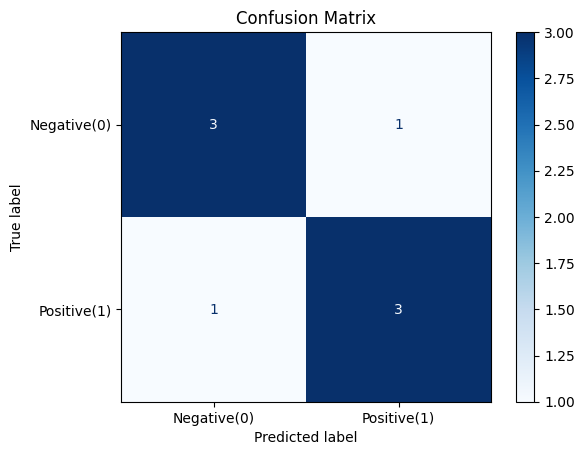

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 가상의 예측 결과
y_true = [0, 1, 0, 1, 0, 0, 1, 1]
y_pred = [0, 0, 0, 1, 0, 1, 1, 1]

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative(0)", "Positive(1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
# Confusion Matrix:
#  [[3 1]
#  [1 3]]

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import plotly.figure_factory as ff
import numpy as np

cm = confusion_matrix(y_test, fakepred, labels=[0, 1])  # 레이블 고정 추천함. 싫으면 말구요

ann = np.array([
    [f"TN={cm[0,0]}", f"FP={cm[0,1]}"],
    [f"FN={cm[1,0]}", f"TP={cm[1,1]}"]
])

fig = ff.create_annotated_heatmap(
    z=cm,
    x=["예측=0", "예측=1"],
    y=["실제=0", "실제=1"],
    annotation_text=ann,
    colorscale="Blues", showscale=True
)
fig.update_layout(
    title="Confusion Matrix (Dummy: all-zero)",
    xaxis=dict(title="Predicted"),
    yaxis=dict(title="Actual"),
    template="plotly_dark"
)
fig.show()

# classification_report 출력
print(classification_report(y_test, fakepred, digits=3, zero_division=0))

              precision    recall  f1-score   support

           0      0.900     1.000     0.947       324
           1      0.000     0.000     0.000        36

    accuracy                          0.900       360
   macro avg      0.450     0.500     0.474       360
weighted avg      0.810     0.900     0.853       360



### 혼동행렬 해석 연습

위 결과를 보면:
- **TN=324**: 음성(0)을 음성으로 맞춤 → 많음 (좋음)
- **FP=0**: 음성을 양성으로 틀림 → 없음
- **FN=36**: 양성(1)을 음성으로 틀림 → **전부!** (문제!)
- **TP=0**: 양성을 양성으로 맞춤 → 없음 (큰 문제!)

> **양성을 하나도 못 찾았는데 정확도는 90%!**  
> 혼동행렬을 보면 문제가 바로 보임

---
## Part 4. 핵심 지표: Precision, Recall, F1

### 공식

| 지표 | 공식 | 의미 |
|------|------|------|
| **Accuracy** | (TP + TN) / 전체 | 전체 중 맞춘 비율 |
| **Precision** | TP / (TP + FP) | 양성 예측 중 실제 양성 |
| **Recall** | TP / (TP + FN) | 실제 양성 중 찾은 비율 |
| **F1** | 2 × (P × R) / (P + R) | Precision과 Recall의 조화평균 |

### 다시 정리 호호

- **Precision(정밀도)**: 양성이라고 했는데, 진짜 양성이 맞나?
    - 높으면 → **오탐(FP)이 적음**
    - 예: 스팸 필터가 정상 메일을 스팸으로 잘못 분류하면 안 됨

- **Recall(재현율)**: 진짜 양성 중에서 얼마나 찾았나?
    - 높으면 → **누락(FN)이 적음**
    - 예: 암 진단에서 암 환자를 놓치면 안 됨
- **F1**: Precision과 Recall의 조화평균
    - 둘 중 하나가 0이면 F1도 0에 가까워짐(균형을 강하게 요구)
    - 결국 P/R은 FP/FN 비용을 반영한 의사결정 지표임

![Recall: 놓치지 않았나?](스크린샷%202026-02-09%20오후%202.33.22.png)

![Precision: 헛발질 안 했나?](스크린샷%202026-02-09%20오후%202.33.36.png)

![F1 Score: 균형의 미학](스크린샷%202026-02-09%20오후%202.33.57.png)

### 업무에 따른 중요도

| 상황 | 더 중요한 지표                   | 이유 |
|------|----------------------------|------|
| **스팸 메일 필터** | Precision                  | 정상 메일을 스팸으로 분류하면 안 됨 |
| **암 진단** | Recall                     | 암 환자를 놓치면 생명 위험 |
| **금융 사기 탐지** | Recall                     | 사기를 놓치면 큰 손실 |
| **추천 시스템** | Precision/Recall/랭킹(TOP-K) | 잘못된 추천은 사용자 이탈 유발 |

> **무엇을 틀리면 더 큰 문제인가?**를 먼저 생각하기

### 기준선 모델: Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=50, random_state=42).fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
# Logistic Accuracy: 1.0

Logistic Accuracy: 1.0


/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning:

divide by zero encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning:

overflow encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning:

invalid value encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

divide by zero encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

overflow encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

invalid value encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-package

In [33]:
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_lr))

prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='macro', zero_division=0)
prec_weight, rec_weight, f1_weight, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Macro     P:{prec_macro:.3f} R:{rec_macro:.3f} F1:{f1_macro:.3f}")
print(f"Weighted  P:{prec_weight:.3f} R:{rec_weight:.3f} F1:{f1_weight:.3f}")

# Balanced Accuracy: 1.0
# Macro     P:1.000 R:1.000 F1:1.000
# Weighted  P:1.000 R:1.000 F1:1.000

Balanced Accuracy: 1.0
Macro     P:1.000 R:1.000 F1:1.000
Weighted  P:1.000 R:1.000 F1:1.000


### 평균 방식 요약

| 평균 방식 | 의미 | 언제 쓰나 | 
|----------|------|----------|
| **Balanced Accuracy** | 클래스별 Recall 평균 | 불균형에서 공정한 평가 |
| **Macro** | 클래스별 균등 평균 | 소수 클래스도 중요할 때 | 
| **Weighted** | 표본 수 가중 평균 | 전체 분포 반영 (불균형일수록 Accuracy와 비슷하게 보일 수 있음)|


### 차이를 한눈에 보는 표

| 지표 | 불균형에 강함 | 보는 관점 |
|------|:-------:|----------|
| **Accuracy** |    X    | 전체 맞춘 비율 |
| **Macro** |    O    | 클래스별 공평 |
| **Balanced Accuracy** |    O    | 클래스별 놓침여부 평균|
| **Weighted** |   세모    | 분포 반영(다수 클래스 영향 큼) |

데이터가 불균형 할수록
Accuracy나 Weighted만 보면 착시가 생길 수 있음
그래서 Macro나 Balanced Accuracy로
‘각 클래스를 놓치지 않았는지’를 같이 봐야 함

> **데이터 분포에 따라, 모델의 성능을 다른 채점 기준으로도 확인해야 함**

---
## Part 5. 임곗값(Threshold) = 정책 선택

### 임곗값이란?

분류 모델은 보통 **확률**을 출력합니다.  
예: "이 메일이 스팸일 확률 = 0.7"

기본적으로 **0.5**를 기준으로:
- 확률 ≥ 0.5 → 양성(1)
- 확률 < 0.5 → 음성(0)

하지만 이 기준(임곗값)을 **바꿀 수 있음!**

### 임곗값을 바꾸면?

| 임곗값 | Recall | Precision | 의미 |
|--------|--------|-----------|------|
| 낮춤 (0.3) | ↑ | ↓ | 더 많이 양성으로 잡음 (누락↓, 오탐↑) |
| 높임 (0.7) | ↓ | ↑ | 확실할 때만 양성 (오탐↓, 누락↑) |

> **임곗값 조절 = 정책 선택**

In [34]:
import pandas as pd

# 모델이 예측한 1(양성)이 될 확률
y_prob = np.array([0.1, 0.4, 0.45, 0.6, 0.8, 0.9])
y_true_label = np.array([0, 0, 1, 0, 1, 1])

def get_metrics_by_threshold(y_true, y_prob, threshold):
    # threshold보다 크면 1, 아니면 0으로 예측
    y_pred_custom = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_true, y_pred_custom, zero_division=0)
    recall = recall_score(y_true, y_pred_custom)
    
    return precision, recall

# 임곗값 0.3, 0.5, 0.7 비교
results = []
for th in [0.3, 0.5, 0.7]:
    p, r = get_metrics_by_threshold(y_true_label, y_prob, th)
    results.append({"Threshold": th, "Precision": p, "Recall": r})

print(pd.DataFrame(results))
# Threshold  Precision    Recall
# 0        0.3   0.600000  1.000000
# 1        0.5   0.666667  0.666667
# 2        0.7   1.000000  0.666667

   Threshold  Precision    Recall
0        0.3   0.600000  1.000000
1        0.5   0.666667  0.666667
2        0.7   1.000000  0.666667


In [35]:
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

digits = load_digits()
# 7이면 1(Positive), 아니면 0(Negative)
y_is7 = (digits.target == 7).astype(int)

X_pca10 = PCA(n_components=10, random_state=42).fit_transform(digits.data)

X_train_7, X_test_7, y_train_7, y_test_7 = train_test_split(
    X_pca10, y_is7, test_size=0.2, stratify=y_is7, random_state=11
)

lr_7 = LogisticRegression(max_iter=5000, C=0.1, random_state=42)
lr_7.fit(X_train_7, y_train_7)

proba_7 = lr_7.predict_proba(X_test_7)[:, 1]

thr_list = np.round(np.arange(0.1, 1.0, 0.1), 2)

rows = []
for thr in thr_list:
    y_hat = (proba_7 >= thr).astype(int)
    rows.append([
        thr,
        precision_score(y_test_7, y_hat, zero_division=0),
        recall_score(y_test_7, y_hat, zero_division=0),
        f1_score(y_test_7, y_hat, zero_division=0),
        accuracy_score(y_test_7, y_hat)
    ])

thr_table = pd.DataFrame(rows, columns=["threshold","precision","recall","f1","accuracy"])
display(thr_table)

best = thr_table.iloc[thr_table['f1'].idxmax()]
print(f"[F1 최대] thr={best['threshold']:.2f}, P={best['precision']:.3f}, R={best['recall']:.3f}, F1={best['f1']:.3f}")

target_recall = 0.90
cand = thr_table[thr_table['recall'] >= target_recall].sort_values('threshold')
print(f"[Recall≥{target_recall:.2f}]",
      "없음" if cand.empty else f"thr={cand.iloc[0]['threshold']:.2f}, P={cand.iloc[0]['precision']:.3f}, F1={cand.iloc[0]['f1']:.3f}")

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning:

divide by zero encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning:

overflow encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning:

invalid value encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

divide by zero encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

overflow encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

invalid value encountered in matmul

/Users/yoonseokim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:

,threshold,precision,recall,f1,accuracy
0,0.1,0.708333,0.944444,0.809524,0.955556
1,0.2,0.772727,0.944444,0.850000,0.966667
2,0.3,0.809524,0.944444,0.871795,0.972222
3,0.4,0.829268,0.944444,0.883117,0.975000
4,0.5,0.850000,0.944444,0.894737,0.977778
5,0.6,0.864865,0.888889,0.876712,0.975000
6,0.7,0.911765,0.861111,0.885714,0.977778
7,0.8,0.967742,0.833333,0.895522,0.980556
8,0.9,0.961538,0.694444,0.806452,0.966667


[F1 최대] thr=0.80, P=0.968, R=0.833, F1=0.896
[Recall≥0.90] thr=0.10, P=0.708, F1=0.810


In [36]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=thr_table["threshold"], y=thr_table["precision"],
                         mode="lines", name="Precision",
                         line=dict(dash="dash", color="cyan")))
fig.add_trace(go.Scatter(x=thr_table["threshold"], y=thr_table["recall"],
                         mode="lines", name="Recall",
                         line=dict(color="magenta")))
fig.add_trace(go.Scatter(x=thr_table["threshold"], y=thr_table["f1"],
                         mode="lines", name="F1",
                         line=dict(color="yellow")))

fig.update_layout(title="임곗값 변화에 따른 Precision/Recall/F1 (digits: 7 vs others)",
                  xaxis_title="Threshold",
                  yaxis_title="Score",
                  yaxis=dict(range=[0,1]),
                  template="plotly_dark")
fig.show()

### 임곗값 선택 가이드(정답이 없음)

```
목표가 무엇인가?
    ├── Recall이 중요 (암 진단) → 임곗값 낮추기 (0.3~0.4)
    ├── Precision이 중요 (스팸) → 임곗값 높이기 (0.6~0.7)
    └── 균형이 중요 → F1이 최대인 임곗값 선택
```

> **임곗값은 "정답"이 없음.** 업무 목표에 따라 선택해야 함!!!!!! 강조 * 999999

---
## Part 6. ROC 곡선과 AUC, PR 곡선(AP)

### ROC 곡선이란?

- **X축**: FPR (False Positive Rate) = FP / (FP + TN)
- **Y축**: TPR (True Positive Rate) = Recall = TP / (TP + FN)
- 임곗값을 0에서 1까지 바꾸며 그린 곡선

**해석**:
- 곡선이 **왼쪽 위**로 갈수록 좋음
-
- **AUC** (Area Under Curve): 곡선 아래 면적
  - 0.5 = 랜덤
  - 1.0 = 완벽

> ROC-AUC는 **Positive와 Negative의 점수 분포가 통계적으로 얼마나 잘 구분되는지**를 보는 점수.
>
> 임곗값을 아무렇게나 바꿔도 Positive와 Negative가 잘 갈라지면 AUC가 높음.

![ROC의 핵심 질문: 기준을 바꿔도 흔들리지 않는가?](스크린샷%202026-02-09%20오후%202.35.45.png)

![ROC & AUC: 통계적 구분 능력](스크린샷%202026-02-13%20오후%202.17.10.png)

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 임의의 데이터 (훈련된 모델의 예측 확률이라고 가정)
np.random.seed(42)
y_real = np.random.randint(0, 2, 100)
y_scores = np.random.rand(100)

# ROC, PR 값 계산
fpr, tpr, _ = roc_curve(y_real, y_scores)
roc_auc = roc_auc_score(y_real, y_scores)

precision, recall, _ = precision_recall_curve(y_real, y_scores)
pr_ap = average_precision_score(y_real, y_scores)

# 시각화 (Plotly)
fig = make_subplots(rows=1, cols=2, subplot_titles=("ROC Curve", "Precision-Recall Curve"))

# 1. ROC Curve
fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f"ROC (AUC = {roc_auc:.2f})", mode='lines', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name="Random", mode='lines', line=dict(dash='dash', color='gray')), row=1, col=1)

# 2. PR Curve
fig.add_trace(go.Scatter(x=recall, y=precision, name=f"PR (AP = {pr_ap:.2f})", mode='lines', line=dict(color='red')), row=1, col=2)

fig.update_layout(
    title="ROC vs PR Curve 비교",
    template="plotly_dark",  # 혹은 "plotly_white"
    width=900, height=450
)
fig.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import plotly.graph_objects as go

# Dummy: 점수 0만 내는 모델(랜덤 기준선 비교용)
y_proba_dummy = np.zeros(len(y_test_7))

fpr_lr, tpr_lr, _ = roc_curve(y_test_7, proba_7)
auc_lr = roc_auc_score(y_test_7, proba_7)

fpr_dummy, tpr_dummy, _ = roc_curve(y_test_7, y_proba_dummy)
auc_dummy = roc_auc_score(y_test_7, y_proba_dummy)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_lr, y=tpr_lr,
    mode="lines",
    name=f"Logistic (AUC={auc_lr:.3f})",
    line=dict(color="cyan", width=3)
))

fig.add_trace(go.Scatter(
    x=fpr_dummy, y=tpr_dummy,
    mode="lines",
    name=f"Dummy (AUC={auc_dummy:.3f})",
    line=dict(color="red", dash="dash")
))

fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode="lines",
    name="Random (AUC=0.5)",
    line=dict(color="gray", dash="dot")
))

fig.update_layout(
    title="ROC Curve Comparison (digits: 7 vs others) — Dummy vs Logistic",
    xaxis_title="FPR (False Positive Rate)",
    yaxis_title="TPR (Recall)",
    xaxis=dict(range=[0,1]),
    yaxis=dict(range=[0,1]),
    template="plotly_dark"
)

fig.show()
print(f"[ROC-AUC] Logistic (digits 7): {auc_lr:.3f} | Dummy: {auc_dummy:.3f} | Random≈0.500")
# [ROC-AUC] Logistic (digits 7): 0.994 | Dummy: 0.500 | Random≈0.500

[ROC-AUC] Logistic (digits 7): 0.994 | Dummy: 0.500 | Random≈0.500


In [38]:
import pandas as pd
import plotly.express as px

auc_df = pd.DataFrame({
    "Model": ["Dummy", "Logistic"],
    "ROC-AUC": [auc_dummy, auc_lr]
})

fig_auc = px.bar(
    auc_df, x="Model", y="ROC-AUC", text="ROC-AUC",
    template="plotly_dark", range_y=[0,1],
    title="ROC-AUC 비교 (Dummy vs Logistic)"
)
fig_auc.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_auc.show()

![PR Curve & AP: 랭킹의 품격](스크린샷%202026-02-13%20오후%202.19.16.png)

### PR 곡선이란?

- **X축**: Recall
- **Y축**: Precision
- **불균형 데이터**에서 더 직관적

**해석**:
- 곡선이 **오른쪽 위**로 갈수록 좋음
- **AP** (Average Precision): PR 곡선 아래 면적
- 기준선 = 양성 비율 (예: 10%)

> **직관 한 줄**: AP는 **Positive를 점수 기준으로 정렬했을 때, 위쪽에 얼마나 모여 있는지** 보는 지표.
>
> 즉, **AP = Positive 랭킹 품질**!  
> Positive가 드문 상황에서도 "높은 점수를 받은 것들이 진짜 Positive인가?"를 평가함

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import plotly.graph_objects as go

prec, rec, thr = precision_recall_curve(y_test_7, proba_7)
ap = average_precision_score(y_test_7, proba_7)

pos_rate = y_test_7.mean()

fig_pr = go.Figure()

fig_pr.add_trace(go.Scatter(
    x=rec, y=prec,
    mode="lines", name=f"PR (AP={ap:.3f})",
    line=dict(color="magenta", width=3)
))

fig_pr.add_trace(go.Scatter(
    x=[0,1], y=[pos_rate, pos_rate],
    mode="lines", name=f"Baseline pos rate={pos_rate:.2f}",
    line=dict(dash="dash", color="grey")
))

fig_pr.update_layout(
    title="Precision-Recall Curve (digits: 7 vs others)",
    xaxis_title="Recall",
    yaxis_title="Precision",
    template="plotly_dark",
    yaxis=dict(range=[0,1]),
    xaxis=dict(range=[0,1])
)

fig_pr.show()

### ROC vs PR: 언제 무엇을 볼까?

| 곡선 | 특징 | 언제 쓰나 |
|------|------|----------|
| **ROC-AUC** | 임곗값 전체 분류력 | 클래스가 균형일 때 |
| **PR-AP** | 양성 기준 분류력 | **불균형 데이터**에서 더 직관적 |

> **가장 안전한 방법: 두 그래프를 함께 보는 습관!**

In [40]:
import plotly.graph_objects as go

metrics = ["ROC Curve", "PR Curve"]
x_axis = [
    "FPR (False Positive Rate)",
    "Recall (재현율)"
]
y_axis = [
    "TPR (True Positive Rate, 재현율)",
    "Precision (정밀도)"
]
interpret = [
    "곡선이 왼쪽 위로 갈수록 좋음 (AUC↑)",
    "곡선이 오른쪽 위로 갈수록 좋음 (AP↑)"
]
when_use = [
    "클래스가 비교적 균형 있을 때 전체 성능 요약",
    "불균형 데이터에서 더 직관적"
]

fig = go.Figure(data=[go.Table(
    header=dict(
        values=["지표", "X축", "Y축", "해석", "언제 유용한가"],
        fill_color="purple", align="center", font=dict(color="white")
    ),
    cells=dict(
        values=[metrics, x_axis, y_axis, interpret, when_use],
        fill_color=[["black","black"]],
        align="center",
        font=dict(color="white")
    )
)])

fig.update_layout(
    title="ROC vs PR Curve 비교",
    template="plotly_dark"
)

fig.show()

---
## 오늘의 정리

| 개념 | 핵심 | 언제 중요한가 |
|------|------|-------------|
| 정확도 | 전체 중 맞춘 비율 | 균형 데이터에서만 신뢰 |
| 혼동행렬 | TP/FP/FN/TN 분포 확인 | 항상 확인! |
| Precision | 양성 예측 중 실제 양성 | 오탐 줄여야 할 때 |
| Recall | 실제 양성 중 찾은 비율 | 누락 줄여야 할 때 |
| F1 | Precision과 Recall 균형 | 둘 다 중요할 때 |
| 임곗값 | 확률 → 예측 변환 기준 | 정책 선택 |
| ROC-AUC | 전체 임곗값 분류력 | 균형 데이터 |
| PR-AP | 양성 기준 분류력 | 불균형 데이터 |

> **기억할 문장**: "정확도만 보지 말고, 무엇을 맞추고 무엇을 틀렸는지 확인하라!"

---
## 다음 시간 예고
> 오늘 분류 모델의 평가지표를 배웠으니,
> 다음시간부터는 분류 ㄱㄱ